# LoRA vs original Nina: MSE per layer

Load pretrained NinaSR and the trained LoRA checkpoint. For each conv, merge LoRA into an effective kernel and compute **MSE vs the original weights**.

In [6]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch
import torch.nn as nn

REPO = Path(".").resolve()
sys.path.insert(0, str(REPO))

from bitrate_sr.data import build_nina_lora, build_sr_pretrained
from bitrate_sr.lora import LoRAConv2d

# CKPT = REPO / "img0425_nina_psnr35_lam0.2_r4_latest.pt"
CKPT = REPO / "img0323_nina_psnr35_lam0.2_r4_latest.pt"

DEVICE = torch.device("cpu")

orig = build_sr_pretrained("nina", DEVICE)
lora = build_nina_lora(DEVICE, lora_r=4, lora_alpha=8.0)

ckpt = torch.load(CKPT, map_location="cpu", weights_only=False)
state = ckpt["model_supres"] if isinstance(ckpt, dict) and "model_supres" in ckpt else ckpt
lora.load_state_dict(state, strict=False)
orig.eval()
lora.eval()
print("original Nina + trained LoRA loaded")


Cached: /Users/tienti/.cache/torch/hub/checkpoints/ninasr_b0_x2.pt
Cached: /Users/tienti/.cache/torch/hub/checkpoints/ninasr_b0_x2.pt
Nina+LoRA: layers=42, trainable=23196, total=123374
original Nina + trained LoRA loaded


layer                                                    MSE(eff, orig)   MSE(frozen, orig)   ||delta||
head.1                                                     4.406055e-05        0.000000e+00      0.1380
body.0.body.0                                              3.695904e-04        0.000000e+00      1.3050
body.0.body.2.body.1                                       3.469416e-05        0.000000e+00      0.0942
body.0.body.2.body.3                                       2.421369e-02        0.000000e+00      2.4897
body.0.body.3                                              2.046194e-04        0.000000e+00      0.9710
body.1.body.0                                              5.616945e-05        0.000000e+00      0.5088
body.1.body.2.body.1                                       5.629942e-04        0.000000e+00      0.3796
body.1.body.2.body.3                                       3.630149e-03        0.000000e+00      0.9640
body.1.body.3                                              5.795

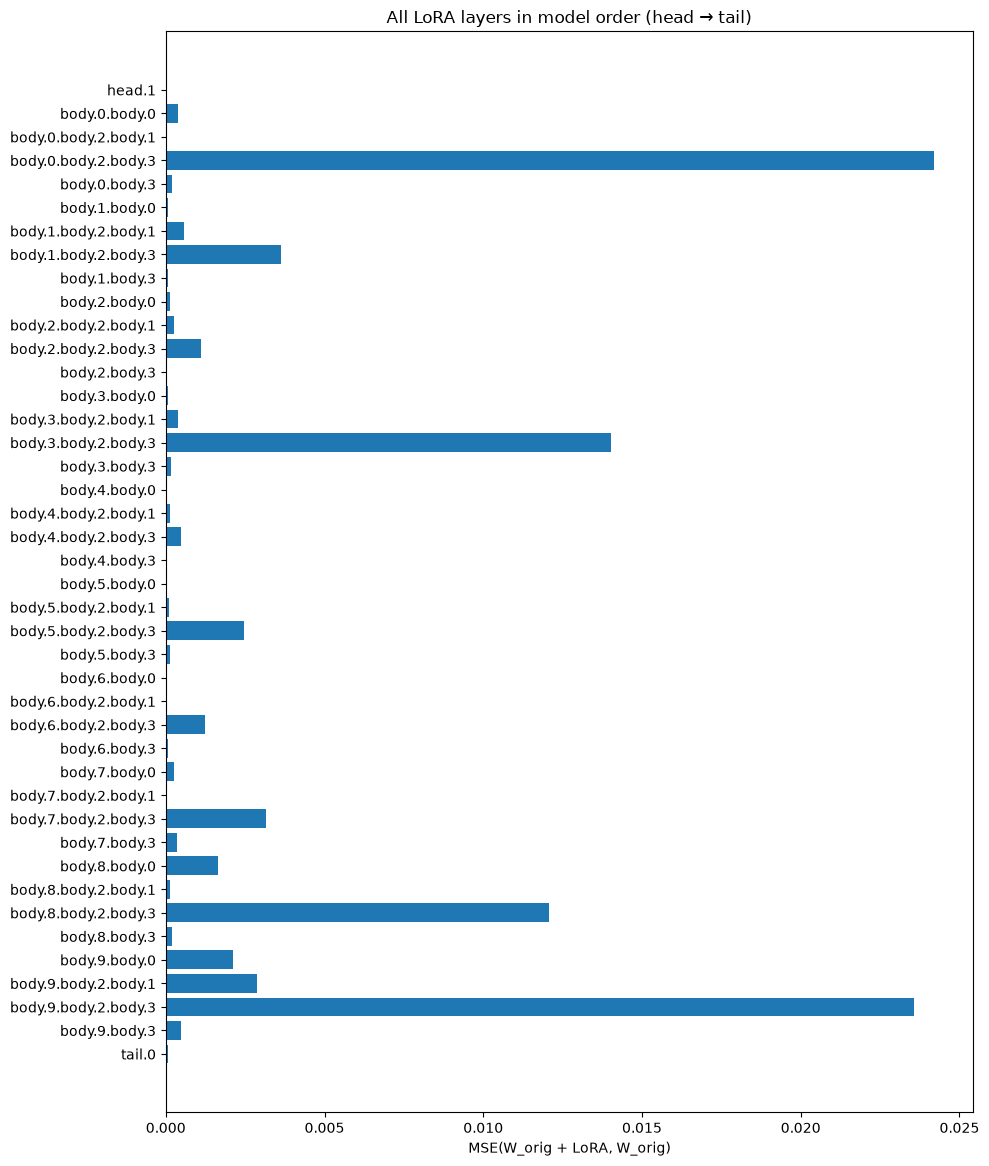

In [5]:
def lora_delta_kernel(mod: LoRAConv2d) -> torch.Tensor:
    # A: (r, Cin, kH, kW), B: (Cout, r, 1, 1) → same shape as conv.weight
    A = mod.lora_A.weight.detach().float()
    B = mod.lora_B.weight.detach().float()[:, :, 0, 0]
    return mod.scaling * torch.einsum("or,rijk->oijk", B, A)


orig_convs = {n: m for n, m in orig.named_modules() if isinstance(m, nn.Conv2d)}

rows = []
for name, lmod in lora.named_modules():  # model order: head → body.0 → … → tail
    if not isinstance(lmod, LoRAConv2d):
        continue
    if name not in orig_convs:
        print("skip (no orig conv):", name)
        continue
    W_orig = orig_convs[name].weight.detach().float()
    W_base = lmod.conv.weight.detach().float()
    delta = lora_delta_kernel(lmod)
    W_eff = W_base + delta
    mse = float(torch.mean((W_eff - W_orig) ** 2))
    mse_frozen = float(torch.mean((W_base - W_orig) ** 2))
    rows.append((name, mse, mse_frozen, float(delta.norm())))

print(f"{'layer':55s}  {'MSE(eff, orig)':>14s}  {'MSE(frozen, orig)':>18s}  {'||delta||':>10s}")
for name, mse, mse_f, nd in rows:
    print(f"{name:55s}  {mse:14.6e}  {mse_f:18.6e}  {nd:10.4f}")

imax = max(range(len(rows)), key=lambda i: rows[i][1])
print("\nmost changed vs original Nina:", rows[imax][0])

fig, ax = plt.subplots(figsize=(10, max(4, 0.28 * len(rows))))
ax.barh([r[0] for r in rows][::-1], [r[1] for r in rows][::-1])  # first layer at top
ax.set_xlabel("MSE(W_orig + LoRA, W_orig)")
ax.set_title("All LoRA layers in model order (head → tail)")
plt.tight_layout()
plt.show()

layer                                                    MSE(eff, orig)   MSE(frozen, orig)   ||delta||
head.1                                                     1.506241e-04        0.000000e+00      0.2551
body.0.body.0                                              1.287995e-03        0.000000e+00      2.4362
body.0.body.2.body.1                                       8.174327e-05        0.000000e+00      0.1447
body.0.body.2.body.3                                       3.364814e-03        0.000000e+00      0.9281
body.0.body.3                                              7.251435e-05        0.000000e+00      0.5781
body.1.body.0                                              1.256561e-04        0.000000e+00      0.7609
body.1.body.2.body.1                                       7.748781e-05        0.000000e+00      0.1408
body.1.body.2.body.3                                       3.365917e-03        0.000000e+00      0.9283
body.1.body.3                                              3.248

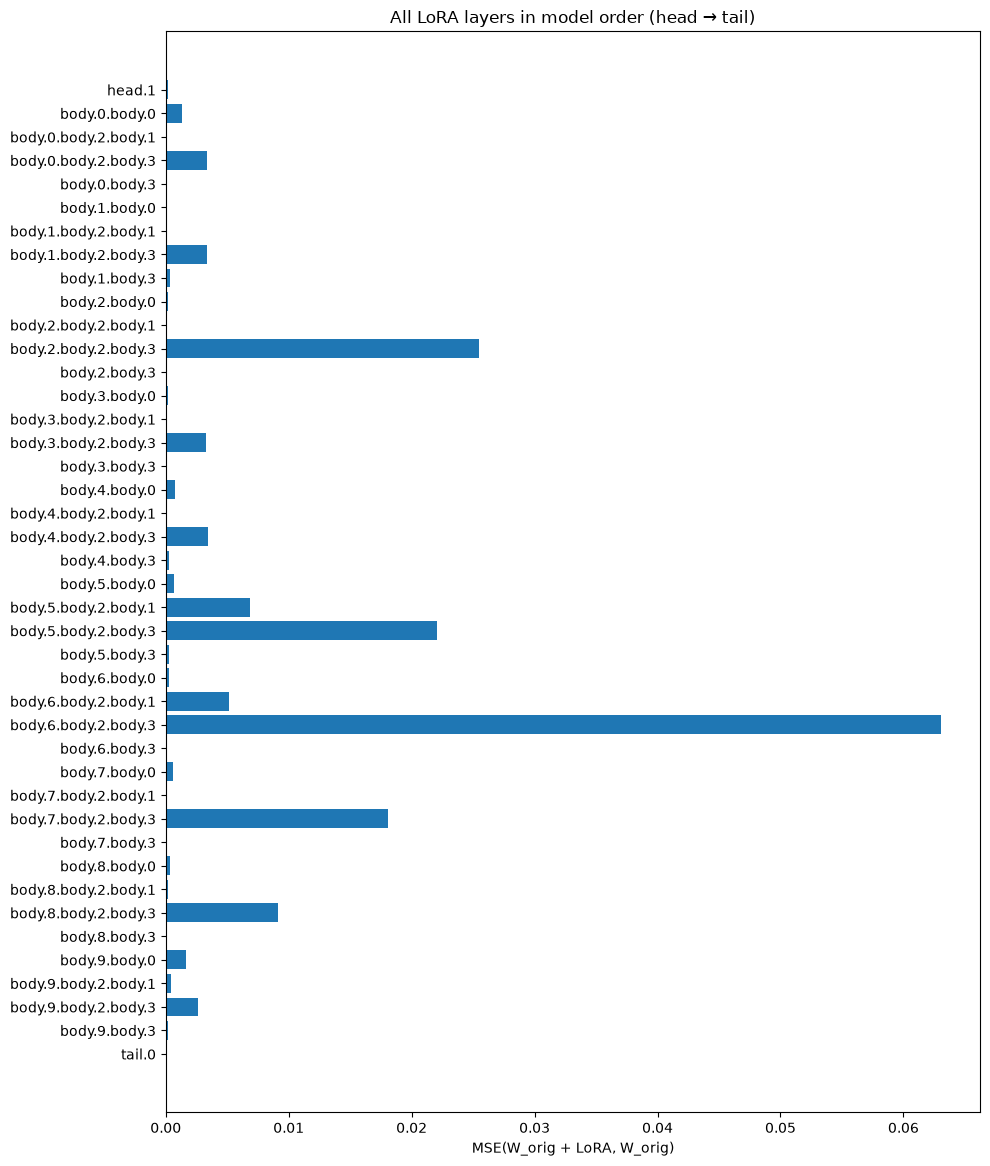

In [7]:
def lora_delta_kernel(mod: LoRAConv2d) -> torch.Tensor:
    # A: (r, Cin, kH, kW), B: (Cout, r, 1, 1) → same shape as conv.weight
    A = mod.lora_A.weight.detach().float()
    B = mod.lora_B.weight.detach().float()[:, :, 0, 0]
    return mod.scaling * torch.einsum("or,rijk->oijk", B, A)


orig_convs = {n: m for n, m in orig.named_modules() if isinstance(m, nn.Conv2d)}

rows = []
for name, lmod in lora.named_modules():  # model order: head → body.0 → … → tail
    if not isinstance(lmod, LoRAConv2d):
        continue
    if name not in orig_convs:
        print("skip (no orig conv):", name)
        continue
    W_orig = orig_convs[name].weight.detach().float()
    W_base = lmod.conv.weight.detach().float()
    delta = lora_delta_kernel(lmod)
    W_eff = W_base + delta
    mse = float(torch.mean((W_eff - W_orig) ** 2))
    mse_frozen = float(torch.mean((W_base - W_orig) ** 2))
    rows.append((name, mse, mse_frozen, float(delta.norm())))

print(f"{'layer':55s}  {'MSE(eff, orig)':>14s}  {'MSE(frozen, orig)':>18s}  {'||delta||':>10s}")
for name, mse, mse_f, nd in rows:
    print(f"{name:55s}  {mse:14.6e}  {mse_f:18.6e}  {nd:10.4f}")

imax = max(range(len(rows)), key=lambda i: rows[i][1])
print("\nmost changed vs original Nina:", rows[imax][0])

fig, ax = plt.subplots(figsize=(10, max(4, 0.28 * len(rows))))
ax.barh([r[0] for r in rows][::-1], [r[1] for r in rows][::-1])  # first layer at top
ax.set_xlabel("MSE(W_orig + LoRA, W_orig)")
ax.set_title("All LoRA layers in model order (head → tail)")
plt.tight_layout()
plt.show()

## Parameter count per layer (model order)

Paste a checkpoint path like in the first cell. Histogram is LoRA trainable params (`lora_A` + `lora_B`) in the same order as the MSE plot.

Cached: /Users/tienti/.cache/torch/hub/checkpoints/ninasr_b0_x2.pt
Nina+LoRA: layers=42, trainable=23196, total=123374
layer                                                     LoRA params   frozen conv
head.1                                                            172           432
body.0.body.0                                                     704          4640
body.0.body.2.body.1                                              160           264
body.0.body.2.body.3                                              160           288
body.0.body.3                                                    1216          4608
body.1.body.0                                                     704          4640
body.1.body.2.body.1                                              160           264
body.1.body.2.body.3                                              160           288
body.1.body.3                                                    1216          4608
body.2.body.0                            

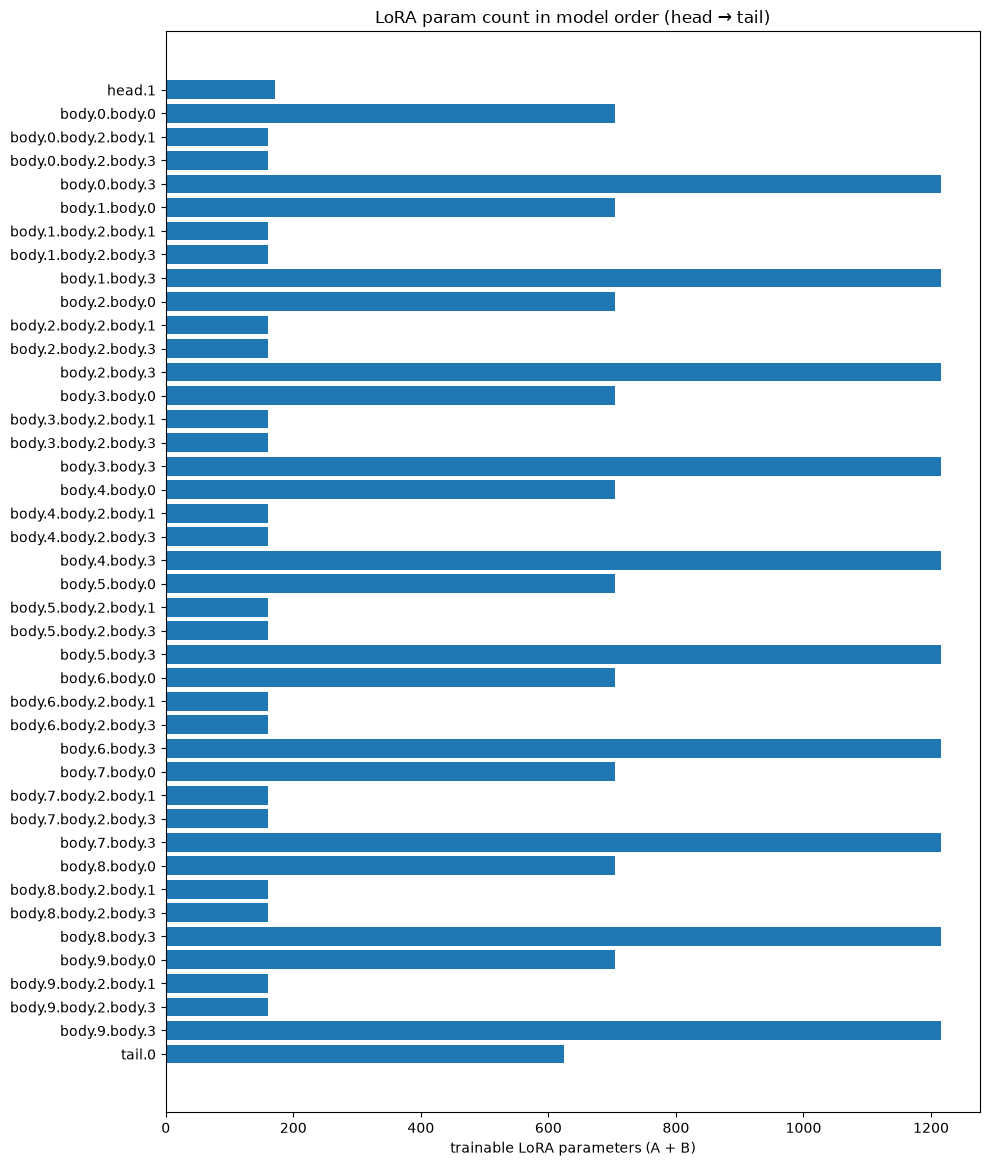

In [8]:
# Paste checkpoint path (same format as CKPT above)
CKPT_PARAMS = REPO / "img0425_nina_psnr35_lam0.2_r4_latest.pt"
# CKPT_PARAMS = Path("/path/to/latest.pt")

ckpt_p = torch.load(CKPT_PARAMS, map_location="cpu", weights_only=False)
state_p = ckpt_p["model_supres"] if isinstance(ckpt_p, dict) and "model_supres" in ckpt_p else ckpt_p
model_p = build_nina_lora(DEVICE, lora_r=4, lora_alpha=8.0)
model_p.load_state_dict(state_p, strict=False)
model_p.eval()

names, n_lora, n_base = [], [], []
for name, mod in model_p.named_modules():
    if not isinstance(mod, LoRAConv2d):
        continue
    nA = mod.lora_A.weight.numel()
    nB = mod.lora_B.weight.numel()
    names.append(name)
    n_lora.append(nA + nB)
    n_base.append(mod.conv.weight.numel() + (0 if mod.conv.bias is None else mod.conv.bias.numel()))

print(f"{'layer':55s}  {'LoRA params':>12s}  {'frozen conv':>12s}")
for n, a, b in zip(names, n_lora, n_base):
    print(f"{n:55s}  {a:12d}  {b:12d}")
print(f"\ntotal LoRA (trainable): {sum(n_lora)}")
print(f"total frozen conv in those layers: {sum(n_base)}")
print("file:", CKPT_PARAMS)

fig, ax = plt.subplots(figsize=(10, max(4, 0.28 * len(names))))
ax.barh(names[::-1], n_lora[::-1])
ax.set_xlabel("trainable LoRA parameters (A + B)")
ax.set_title("LoRA param count in model order (head → tail)")
plt.tight_layout()
plt.show()
